# Selecting Extremely Metal Poor Candidates from DESI DR1

I will apply here what I've learned in the exploration notebooks (e.g., `emfit-vac.ipynb`) to make a selection of EMP candidates.

- Do not limit by NII6583 S/N. Upper limits are useful. Better do a limit on Hb because I will need it to weed out bad measurements
- Ha measurements seem to be off very frequently in the regime of interest. One way to weed them out is to enforce Ha/Hb close to 2.86. A limit of <10 seems to be effective.


In [1]:
import os

import fitsio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.table import Table


In [2]:
columns_to_read = [
    "TARGETID",
    "TARGET_RA",
    "TARGET_DEC",
    "Z",
    "HB_N_FLUX",
    "HB_N_FLUX_ERR",
    "OIII5007_FLUX",
    "OIII5007_FLUX_ERR",
    "HA_N_FLUX",
    "HA_N_FLUX_ERR",
    "NII6583_FLUX",
    "NII6583_FLUX_ERR",
]

emfit_fname = "/mnt/DATA/survey-oficial-releases/DESI/VAC/emfit-dr1-v2.3.1.fits"

data = fitsio.read(emfit_fname, ext=1, columns=columns_to_read)

# The following is necessary to avoid and endianness problem
emfit = pd.DataFrame(
    {
        col: np.asarray(data[col], dtype=data[col].dtype.newbyteorder("<"))
        for col in data.dtype.names
    }
)

In [3]:
selection = emfit.query(
    "HB_N_FLUX / HB_N_FLUX_ERR > 3 "
    "and Z < 0.3 "
    "and OIII5007_FLUX > 0 "
    "and HA_N_FLUX > 0 "
    "and HA_N_FLUX / HB_N_FLUX < 10 "
    "and TARGET_DEC < 10"
).copy()

In [4]:
# selection["R3"] = np.log10(selection["HA_N_FLUX"] / selection["HB_N_FLUX"])  # mistake!
selection["R3"] = np.log10(selection["OIII5007_FLUX"] / selection["HB_N_FLUX"])

selection["NII_detected"] = (
    selection["NII6583_FLUX"] / selection["NII6583_FLUX_ERR"] > 3
)
selection["N2"] = np.log10(selection["NII6583_FLUX"] / selection["HA_N_FLUX"])
selection["N2_uplim"] = np.log10(
    3 * selection["NII6583_FLUX_ERR"] / selection["HA_N_FLUX"]
)
selection["N2_distilled"] = np.nan
selection.loc[selection["NII_detected"], "N2_distilled"] = selection.loc[
    selection["NII_detected"], "N2"
]
selection.loc[~selection["NII_detected"], "N2_distilled"] = selection.loc[
    ~selection["NII_detected"], "N2_uplim"
]

/mnt/Users/tino/research/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/mnt/Users/tino/research/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [5]:
mask = (selection["N2_distilled"] < -1.5) & (selection["R3"] < 0.55)
print(f"Selected {np.sum(mask)} EMP candidates")

Selected 31146 EMP candidates


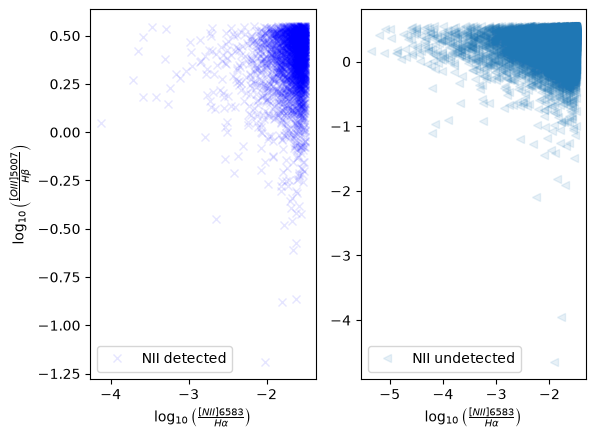

In [6]:
fig, axes = plt.subplots(1, 2)
axes[0].plot(
    selection[mask].loc[selection["NII_detected"], "N2_distilled"],
    selection[mask].loc[selection["NII_detected"], "R3"],
    "x",
    color="blue",
    alpha=0.1,
    label="NII detected",
)

axes[1].plot(
    selection[mask].loc[~selection["NII_detected"], "N2_distilled"],
    selection[mask].loc[~selection["NII_detected"], "R3"],
    "<",
    color="tab:blue",
    alpha=0.1,
    label="NII undetected",
)

axes[0].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[1].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[0].set_ylabel(r"$\log_{10} \left( \frac{[OIII] 5007}{H\beta} \right)$")
axes[0].legend()
axes[1].legend()

## Saving the spectra to make my own measurements

*The part about saving the spectra was moved to a script: `src/00-download-emp-sample.py`.*

In [7]:
Table.from_pandas(selection[mask]).write(
    "../data/emp-candidates-v261018.fits", overwrite=True
)

## Comparison with my measurements

I downloaded the spectra for the selected sources and then re-measured the main strong lines using `src/01-re-measure-lines.py`.

I will explore the results of that.

In [8]:
my_table = Table.read("../data/line-measurements-v261018.fits", format="fits")
print(len(my_table))
np.sum(my_table.columns["status"] == "error")

31146


217

In [9]:
mine = my_table[my_table.columns["status"] != "error"].to_pandas()
prior = selection[mask].copy()
full = pd.merge(prior, mine, on="TARGETID", how="inner")

In [10]:
full.columns

Index(['TARGETID', 'TARGET_RA', 'TARGET_DEC', 'Z', 'HB_N_FLUX',
       'HB_N_FLUX_ERR', 'OIII5007_FLUX', 'OIII5007_FLUX_ERR', 'NII6583_FLUX',
       'NII6583_FLUX_ERR', 'HA_N_FLUX', 'HA_N_FLUX_ERR', 'R3', 'NII_detected',
       'N2', 'N2_uplim', 'N2_distilled', 'input_z', 'z_ha_n2', 'zerr_ha_n2',
       'flux_nii6549', 'fluxerr_nii6549', 'flux_ha', 'fluxerr_ha',
       'flux_nii6585', 'fluxerr_nii6585', 'z_hb', 'zerr_hb', 'flux_hb',
       'fluxerr_hb', 'z_o3_b', 'zerr_o3_b', 'flux_o3_b', 'fluxerr_o3_b',
       'status', 'error'],
      dtype='object')

Text(0, 0.5, 'log Ha from my measurements')

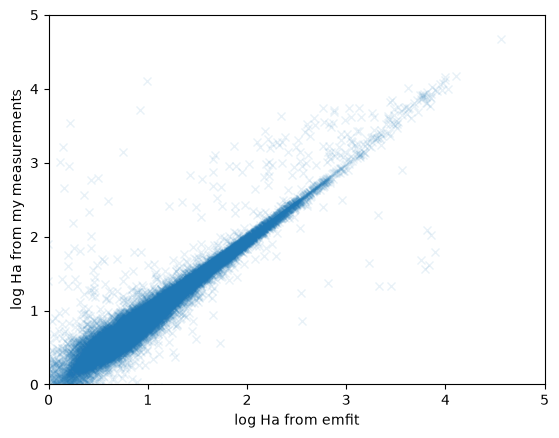

In [11]:
plt.plot(np.log10(full["HA_N_FLUX"]), np.log10(full["flux_ha"]), "x", alpha=0.1)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("log Ha from emfit")
plt.ylabel("log Ha from my measurements")

Text(0, 0.5, 'log Hb from my measurements')

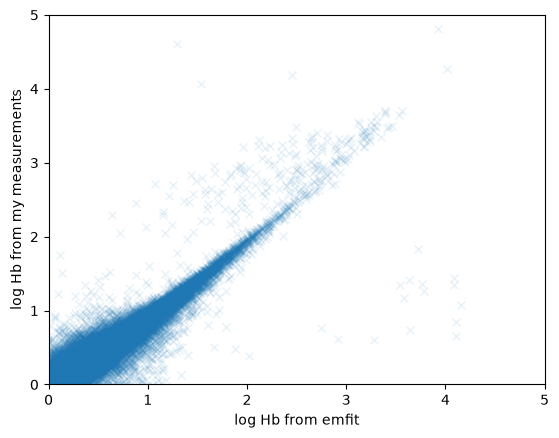

In [12]:
plt.plot(np.log10(full["HB_N_FLUX"]), np.log10(full["flux_hb"]), "x", alpha=0.1)
plt.xlim(0, 5)
plt.ylim(0, 5)
plt.xlabel("log Hb from emfit")
plt.ylabel("log Hb from my measurements")

In [13]:
full["vg_r3"] = np.log10(full["flux_o3_b"] / full["flux_hb"])

full["vg_n2_detected"] = np.log10(full["flux_nii6585"] / full["flux_ha"])
full["vg_n2_undetected"] = np.log10(3 * full["fluxerr_nii6585"] / full["flux_ha"])

detected = full["flux_nii6585"] / full["fluxerr_nii6585"] > 3

full["vg_n2_distilled"] = np.nan
full.loc[detected, "vg_n2_distilled"] = full.loc[detected, "vg_n2_detected"]
full.loc[~detected, "vg_n2_distilled"] = full.loc[~detected, "vg_n2_undetected"]

/mnt/Users/tino/research/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [14]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load("../data/contours.npy")  # This is for reference, comes from SDSS

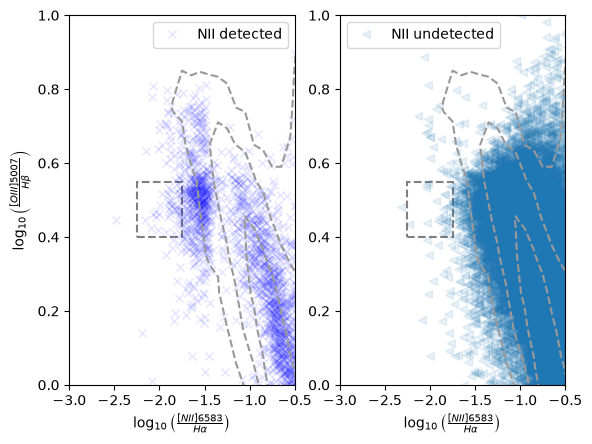

In [15]:
fig, axes = plt.subplots(1, 2)
axes[0].plot(
    full.loc[detected, "vg_n2_distilled"],
    full.loc[detected, "vg_r3"],
    "x",
    color="blue",
    alpha=0.1,
    label="NII detected",
)

axes[1].plot(
    full.loc[~detected, "vg_n2_distilled"],
    full.loc[~detected, "vg_r3"],
    "<",
    color="tab:blue",
    alpha=0.1,
    label="NII undetected",
)

axes[0].contour(
    x_centers,
    y_centers,
    H,
    [10, 100, 1000],
    origin="lower",
    linestyles="--",
    colors="0.6",
)

axes[1].contour(
    x_centers,
    y_centers,
    H,
    [10, 100, 1000],
    origin="lower",
    linestyles="--",
    colors="0.6",
)

rect1 = plt.Rectangle(
    (-2.25, 0.4),
    0.5,
    0.15,
    linewidth=1.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
)

rect2 = plt.Rectangle(
    (-2.25, 0.4),
    0.5,
    0.15,
    linewidth=1.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
)
axes[0].add_patch(rect1)
axes[1].add_patch(rect2)


axes[0].set_xlim(-3, -0.5)
axes[1].set_xlim(-3, -0.5)
axes[0].set_ylim(0, 1.0)
axes[1].set_ylim(0, 1.0)

axes[0].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[1].set_xlabel(r"$\log_{10} \left( \frac{[NII] 6583}{H\alpha} \right)$")
axes[0].set_ylabel(r"$\log_{10} \left( \frac{[OIII] 5007}{H\beta} \right)$")
axes[0].legend()
axes[1].legend()

plt.savefig("../figures/selection.pdf")


In [16]:
detected_in_square = (
    (full["vg_n2_detected"] > -2.25)
    & (full["vg_n2_detected"] < -1.75)
    & (full["vg_r3"] > 0.4)
    & (full["vg_r3"] < 0.55)
)

upper_limit_in_square = (
    (full["vg_n2_undetected"] > -2.25)
    & (full["vg_n2_undetected"] < -2.0)
    & (full["vg_r3"] > 0.4)
    & (full["vg_r3"] < 0.55)
)

In [17]:
select = (detected & detected_in_square) | (~detected & upper_limit_in_square)
np.sum(select)

53

In [18]:
%run ../src/emline-inspect-functions.py

In [19]:
stack = stack_spectra(
    full[select]["TARGETID"],
    full[select],
    spectra_dir="../data/spectra",
    dwave=0.8,
    norm_window=(5950, 6050),
)

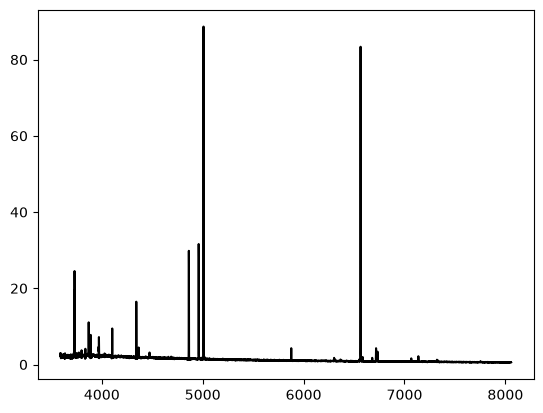

In [20]:
plt.plot(stack["wavelength"], stack["flux"], color="black")

In [21]:
stack_line_groups = {
    "oii3727": ([3727.092, 3729.875], [(3680, 3710), (3745, 3775)]),
    "oiii4363": ([4364.436], [(4300, 4340), (4380, 4420)]),
    "hb": ([4862.683], hb_window),
    "oiii5007": ([5008.240], o3_b_window),
    "ha": ([6564.610], [(6500, 6530), (6600, 6630)]),
    "oii7325": ([7322.01, 7331.68], [(7250, 7290), (7350, 7390)]),
}

stack_fluxes = []
for name, (centers, continuum_windows) in stack_line_groups.items():
    rest_wave = np.asarray(stack["wavelength"])
    flux = np.asarray(stack["flux"])
    ivar = np.asarray(stack["ivar"])
    mask = (
        np.isfinite(rest_wave)
        & np.isfinite(flux)
        & np.isfinite(ivar)
        & (ivar > 0)
        & (rest_wave >= continuum_windows[0][0])
        & (rest_wave <= continuum_windows[1][1])
    )
    fit_wave = rest_wave[mask]
    fit_flux = flux[mask]
    fit_ivar = ivar[mask]
    model = make_gaussian_model(centers)
    p0 = initial_guesses(0.0, centers, continuum_windows, (fit_wave, fit_flux))
    popt, pcov = curve_fit(
        model,
        fit_wave,
        fit_flux,
        p0=p0,
        sigma=1 / np.sqrt(fit_ivar),
        absolute_sigma=True,
        bounds=get_bounds(len(centers)),
    )
    perr = np.sqrt(np.diag(pcov))
    if name == "oii3727":
        component_names = ["oii3726", "oii3729"]
    elif name == "oii7325":
        component_names = ["oii7320", "oii7330"]
    else:
        component_names = [name]
    for component_index, component_name in enumerate(component_names):
        stack_fluxes.append(
            {
                "line": component_name,
                "flux": popt[2 + component_index],
                "flux_err": perr[2 + component_index],
                "sigma": popt[1],
                "sigma_err": perr[1],
            }
        )

stack_fluxes = Table(rows=stack_fluxes).to_pandas().set_index("line")
stack_fluxes

,flux,flux_err,sigma,sigma_err
line,,,,
oii3726,35.001711,0.433031,0.800355,0.007032
oii3729,46.380426,0.470052,0.800355,0.007032
oiii4363,5.202920,0.234745,0.768637,0.039836
hb,60.156715,0.245777,0.794414,0.003434
oiii5007,170.660645,0.324392,0.740732,0.001375
ha,165.328079,0.230562,0.817759,0.001073
oii7320,1.475699,0.094592,1.140535,0.072319
oii7330,1.088628,0.089876,1.140535,0.072319


/tmp/ipykernel_579071/19679699.py:55: UserWarning: Legend does not support handles for QuadContourSet instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()


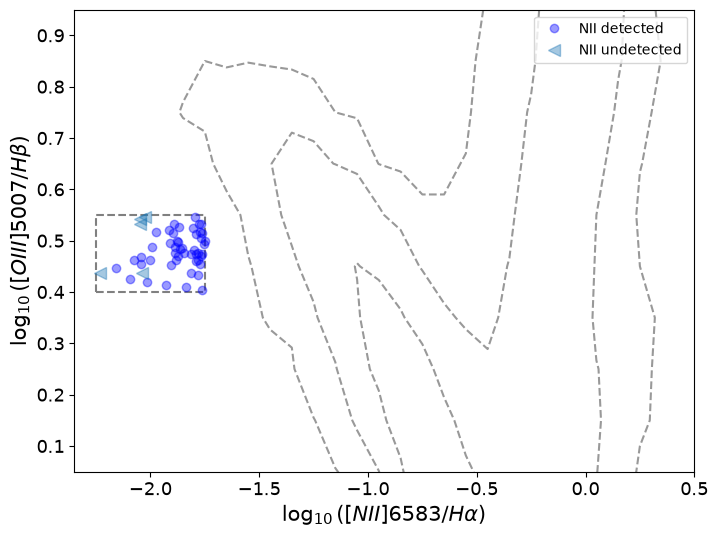

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.plot(
    full.loc[(detected & detected_in_square), "vg_n2_distilled"],
    full.loc[(detected & detected_in_square), "vg_r3"],
    "o",
    color="blue",
    ms=6,
    alpha=0.4,
    label="NII detected",
)

ax.plot(
    full.loc[(~detected & upper_limit_in_square), "vg_n2_distilled"],
    full.loc[(~detected & upper_limit_in_square), "vg_r3"],
    "<",
    color="tab:blue",
    alpha=0.4,
    ms=9,
    label="NII undetected",
)

ax.contour(
    x_centers,
    y_centers,
    H,
    [10, 100, 1000],
    origin="lower",
    linestyles="--",
    colors="0.6",
    label="Local galaxies (SDSS)",
)

rect1 = plt.Rectangle(
    (-2.25, 0.4),
    0.5,
    0.15,
    linewidth=1.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
)
ax.add_patch(rect1)


ax.set_xlim(-2.35, 0.5)
ax.set_ylim(0.05, 0.95)
# ax.set_xlim(-2.55, -1.5)
# ax.set_ylim(0.3, .6)
# increase font of tick labels
ax.tick_params(axis="both", which="major", labelsize=13)

ax.set_xlabel(r"$\log_{10}([NII] 6583 / H\alpha)$", fontsize=15)
ax.set_ylabel(r"$\log_{10}([OIII]5007 / H\beta)$", fontsize=15)
ax.legend()

plt.savefig("../figures/selection.pdf")

In [23]:
import pyneb as pn

In [24]:
o3 = pn.Atom("O", 3)
o2 = pn.Atom("O", 2)

ratio_4363_5007 = (
    stack_fluxes.loc["oiii4363", "flux"] / stack_fluxes.loc["oiii5007", "flux"]
)
o2_den = o2.getTemDen(
    stack_fluxes.loc["oii3726", "flux"] / stack_fluxes.loc["oii3729", "flux"],
    tem=1.25e4,
    wave1=3726,
    wave2=3729,
)
print(o2_den)
ne_val = 130  # cm^-3

te_val = o3.getTemDen(int_ratio=ratio_4363_5007, den=ne_val, wave1=4363, wave2=5007)
te_low = 0.7 * te_val + 3000

te_low_direct = o2.getTemDen(
    int_ratio=(
        stack_fluxes.loc["oii3726", "flux"] + stack_fluxes.loc["oii3729", "flux"]
    )
    / (stack_fluxes.loc["oii7320", "flux"] + stack_fluxes.loc["oii7330", "flux"]),
    den=ne_val,
    wave1=3727,
    wave2=7325,
)

print(f"Electron temperature (Te) from [OIII] 4363/5007 ratio: {te_val:.0f} K")
print(f"Electron temperature (Te) from [OII] 7325/3727 ratio: {te_low_direct:.0f} K")
print(f"Electron temperature (Te OII) from formula: {te_low:.0f} K")

o3_abundance = o3.getIonAbundance(
    tem=te_val,
    den=ne_val,
    int_ratio=stack_fluxes.loc["oiii5007", "flux"]
    / stack_fluxes.loc["hb", "flux"]
    * 100,  # I was missing this factor of 100, which is needed for the calculation
    wave=5007,
)

print(f"OIII abundance : {o3_abundance:.2e}")

o2_abundance = o2.getIonAbundance(
    tem=te_low,
    den=ne_val,
    int_ratio=(
        stack_fluxes.loc["oii3726", "flux"] + stack_fluxes.loc["oii3729", "flux"]
    )
    / stack_fluxes.loc["hb", "flux"],
    wave=3727,
)

print(f"OII abundance : {o2_abundance:.2e}")

total_oh = o3_abundance + o2_abundance
print(f"Total oxygen abundance 12+log(O/H): {12 + np.log10(total_oh):.2f}")


126.5491449784114
Electron temperature (Te) from [OIII] 4363/5007 ratio: 18876 K
Electron temperature (Te) from [OII] 7325/3727 ratio: 27688 K
Electron temperature (Te OII) from formula: 16213 K
OIII abundance : 1.77e-05
OII abundance : 2.08e-07
Total oxygen abundance 12+log(O/H): 7.25


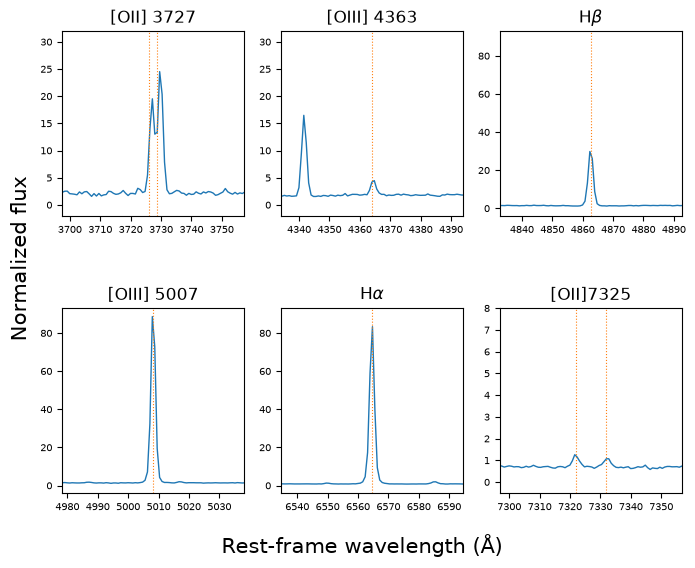

In [25]:
fig, ax_arr = plt.subplots(2, 3, figsize=(8, 6), clear=True)
axes = ax_arr.flatten()

panels = [
    ("[OII] 3727", [3726.032, 3728.815], 30),
    ("[OIII] 4363", [4364], 30),
    (r"H$\beta$", [4862.683], 30),
    ("[OIII] 5007", [5008.24], 30),
    (r"H$\alpha$", [6564.61], 30),
    (r"[OII]7325", [7322.01, 7331.68], 30),
    # (r"[Cl III]5517", [5517.63, 5537.81], 50),
]

for ax, (label, centers, half_width) in zip(axes, panels):
    ax.plot(stack["wavelength"], stack["flux"], color="tab:blue", lw=1)
    for center in centers:
        ax.axvline(center, color="tab:orange", ls=":", lw=0.8)
    center = np.mean(centers)
    ax.set_xlim(center - half_width, center + half_width)
    ax.set_title(label, fontsize=12)
    # ax.set_xlabel("Rest-frame wavelength (Å)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylim(-2, 32)
axes[1].set_ylim(-2, 32)
axes[5].set_ylim(-0.5, 8)
# axes[6].set_ylim(-0.5, 2)

fig.text(0.5, 0.01, "Rest-frame wavelength (Å)", ha="center", fontsize=15)
fig.text(0.06, 0.5, "Normalized flux", va="center", rotation="vertical", fontsize=15)

# fig.tight_layout()
# plt.show()
plt.subplots_adjust(hspace=0.5)

plt.savefig("../figures/stacked-spectrum.pdf")

(array([1., 0., 0., 0., 0., 1., 0., 3., 5., 7., 9., 9., 7., 8., 3.]),
 array([-16.71261671, -16.52844598, -16.34427525, -16.16010452,
        -15.97593379, -15.79176306, -15.60759233, -15.4234216 ,
        -15.23925087, -15.05508014, -14.87090941, -14.68673868,
        -14.50256795, -14.31839722, -14.13422649, -13.95005576]),
 <BarContainer object of 15 artists>)

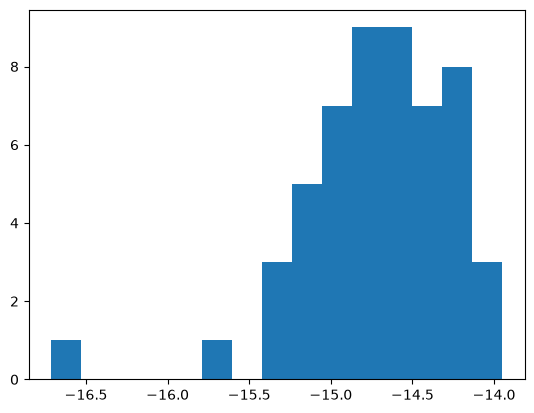

In [26]:
plt.hist(np.log10(full[select]["flux_o3_b"]) - 17, bins=15)

In [27]:
np.sum(np.log10(full[select]["flux_o3_b"]) - 17 > -15)

41

In [28]:
individual_line_groups = {
    "oiii4363": ([4364.436], [(4300, 4340), (4380, 4420)]),
    "oii7325": ([7322.01, 7331.68], [(7250, 7290), (7350, 7390)]),
}

individual_fluxes = []
for _, row in full[select].iterrows():
    targetid = int(row["TARGETID"])
    z = float(row["Z"])
    spec = Table.read(f"../data/spectra/{targetid}.fits", format="fits")
    wave = np.asarray(spec["wavelength"])
    flux = np.asarray(spec["flux"])
    ivar = np.asarray(spec["ivar"])
    rest_wave = wave / (1 + z)

    target_result = {"TARGETID": targetid}
    for name, (centers, continuum_windows) in individual_line_groups.items():
        component_names = ["oii7320", "oii7330"] if name == "oii7325" else [name]
        mask = (
            (rest_wave >= continuum_windows[0][0])
            & (rest_wave <= continuum_windows[1][1])
            & (ivar > 0)
        )

        # Not enough points to constrain the fit for this target/line
        if np.sum(mask) < len(centers) + 3:
            for component_name in component_names:
                target_result[f"{component_name}_flux"] = np.nan
                target_result[f"{component_name}_flux_err"] = np.nan
                target_result[f"{component_name}_snr"] = np.nan
            continue

        model = make_gaussian_model(centers)
        p0 = initial_guesses(z, centers, continuum_windows, (wave, flux))
        try:
            popt, pcov = curve_fit(
                model,
                wave[mask],
                flux[mask],
                p0=p0,
                sigma=1 / np.sqrt(ivar[mask]),
                absolute_sigma=True,
                bounds=get_bounds(len(centers)),
            )
            perr = np.sqrt(np.diag(pcov))
        except RuntimeError:
            popt = np.full(len(p0), np.nan)
            perr = np.full(len(p0), np.nan)

        for component_index, component_name in enumerate(component_names):
            flux_val = popt[2 + component_index]
            flux_err = perr[2 + component_index]
            target_result[f"{component_name}_flux"] = flux_val
            target_result[f"{component_name}_flux_err"] = flux_err
            target_result[f"{component_name}_snr"] = (
                flux_val / flux_err if flux_err > 0 else np.nan
            )

    individual_fluxes.append(target_result)

individual_fluxes = pd.DataFrame(individual_fluxes).set_index("TARGETID")
individual_fluxes


,oiii4363_flux,oiii4363_flux_err,oiii4363_snr,oii7320_flux,oii7320_flux_err,oii7320_snr,oii7330_flux,oii7330_flux_err,oii7330_snr
TARGETID,,,,,,,,,
234532947099648,0.721630,0.247177,2.919487,2.695492e-01,0.184829,1.458370e+00,2.456585e-18,0.242983,1.011011e-17
2389515943542784,11.837447,4.631683,2.555755,6.987413e+00,2.082223,3.355746e+00,3.755382e+00,1.025943,3.660419e+00
2706026876895232,5.158744,0.755134,6.831558,1.099461e-33,0.295770,3.717283e-33,8.712933e-01,0.254588,3.422368e+00
2706107944402944,3.558233,1.399393,2.542697,3.674061e-01,0.437920,8.389799e-01,9.627108e-01,0.517133,1.861632e+00
2706139288436736,3.479859,1.160070,2.999699,5.768493e-01,0.389053,1.482701e+00,2.700932e-01,0.329338,8.201090e-01
2706174780637184,6.728929,1.777406,3.785814,5.411137e-01,0.281050,1.925327e+00,6.224278e-01,0.292526,2.127768e+00
2706193835360256,3.288957,1.477919,2.225397,1.513504e+00,0.466403,3.245059e+00,1.354669e+00,0.564432,2.400059e+00
2706210901983232,4.009165,1.225973,3.270190,8.605914e-01,0.608440,1.414422e+00,1.097361e-01,0.525969,2.086363e-01
2706303013093376,6.757141,1.142870,5.912431,1.585533e+00,0.792901,1.999660e+00,9.705908e-01,0.789302,1.229683e+00


(array([ 7., 15.,  9.,  8.,  6.,  1.,  3.,  2.,  0.,  1.]),
 array([1.06404566e-04, 1.26655670e+00, 2.53300699e+00, 3.79945729e+00,
        5.06590758e+00, 6.33235788e+00, 7.59880817e+00, 8.86525847e+00,
        1.01317088e+01, 1.13981591e+01, 1.26646094e+01]),
 <BarContainer object of 10 artists>)

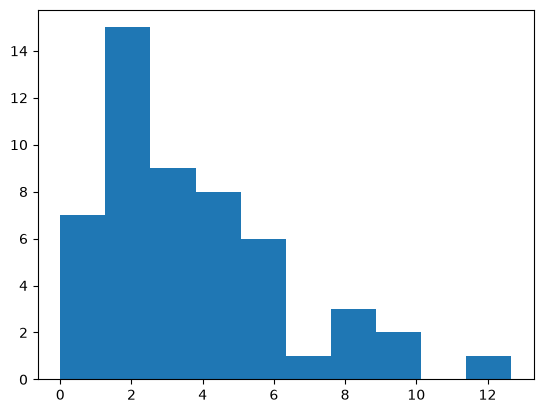

In [29]:
plt.hist(individual_fluxes["oiii4363_snr"])

(array([11.,  6.,  4.,  8., 10.,  2., 10.,  0.,  0.,  2.]),
 array([3.53524084e-34, 5.27076061e-01, 1.05415212e+00, 1.58122818e+00,
        2.10830424e+00, 2.63538031e+00, 3.16245637e+00, 3.68953243e+00,
        4.21660849e+00, 4.74368455e+00, 5.27076061e+00]),
 <BarContainer object of 10 artists>)

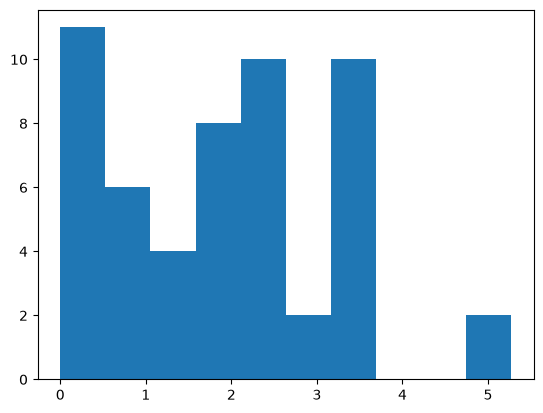

In [30]:
plt.hist(individual_fluxes["oii7330_snr"])

(array([ 6.,  2.,  7., 16.,  5.,  7.,  4.,  2.,  3.,  1.]),
 array([3.71728336e-33, 5.96843133e-01, 1.19368627e+00, 1.79052940e+00,
        2.38737253e+00, 2.98421567e+00, 3.58105880e+00, 4.17790193e+00,
        4.77474506e+00, 5.37158820e+00, 5.96843133e+00]),
 <BarContainer object of 10 artists>)

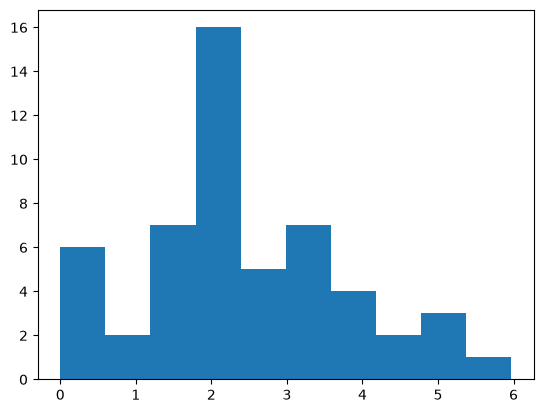

In [31]:
plt.hist(individual_fluxes["oii7320_snr"])

In [32]:
main_stack_targets = pd.merge(
    full[select], individual_fluxes, on="TARGETID", how="inner"
)

In [33]:
Table.from_pandas(main_stack_targets).write(
    "../data/main-stack-targets-261020.fits",
    overwrite=True,
)